- [Gráfico 1](#gr1): taxa de sucesso na realocação. Usuários afetados que foram realocados devidamente dividido pelo total de usuários afetados


- [Gráfico 2](#gr2): Taxa de utilização de Espaço da Rede: que é quão bem a abordagem está aproveitando o espaço de armazenamento disponível após uma falha na rede. Uma taxa alta indica uma boa utilização dos recursos 

- [Gráfico 3](#gr3): -Taxa de perda de benefícios: O quão o usuário foi prejudicado nessa realocação em comparação com a alocação antiga dele


- [Gráfico 4](#gr4): - tempo de realocação

### Configuração inicial

Importando bibliotecas necessárias

In [1]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
import numpy as np
import pandas as pd 
# import seaborn as sns
#import plotly.graph_objects as go
import numpy as np
#import plotly.io as pio
#import plotly.express as px


import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

### Carregamento dos dados

In [2]:
results_flows_directories = glob.glob('../../results/results_flows*/*') # Caso mude a estrutura dos diretórios, esse caminho deve ser alterado
results_flows_directories

['../../results\\results_flows\\goku_backup_s_50_p_4_sfc_on_rel_1',
 '../../results\\results_flows\\goku_s_50_p_4_sfc_on_rel_1',
 '../../results\\results_flows\\g_s_50_p_4_sfc_on_rel_1',
 '../../results\\results_flows\\msf_s_50_p_4_sfc_on_rel_1',
 '../../results\\results_flows\\musfico_s_50_p_4_sfc_on_rel_1']

In [3]:
for alg_dir in results_flows_directories:
    simulacoes_okays = 0
    simu_exec_name = alg_dir.split('/')[-1].split('_')
    
    if simu_exec_name [2] == 'backup':
        alg_name = 'goku_backup'
    else:
        alg_name = simu_exec_name[1].split(f'\\')[1]
    reliability = simu_exec_name[-1]

# Gráfico 1 <a id="gr1"></a>

taxa de sucesso na realocação. Usuários afetados que foram realocados devidamente dividido pelo total de usuários afetados


In [4]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        
        if simu_exec_name [2] == 'backup':
            alg_name = 'goku_backup'
        else:
            alg_name = simu_exec_name[1].split(f'\\')[1]
        reliability = simu_exec_name[-1]
        if alg_name == 'g':
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'OSCIM'
        if alg_name == 'goku_backup':
            alg_name = 'Backup OSCIM'
        if alg_name == 'musfico':
            alg_name = 'MuSFiCO'

        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'reliability': [reliability], 'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:
            log_simu[alg_name]['reliability'].append(reliability)
            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                #print(simulation_df)
                sfc_id_values = simulation_df['sfc_id'].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            simulation_is_success = 'sfc_cache_p4_50' in simulation_df['sfc_id'].values
            #print(simulation_is_success)
            
            if simulation_is_success: 
                # Seleciona as métricas relevantes
                simulation_df = simulation_df[metricas_coleta]
                
                # Remove as linhas onde a coluna 'success' é 'None'
                simulation_df = simulation_df[simulation_df['success'] != 'None']

                # Filtra o DataFrame removendo as linhas onde 'sfc_recovered' é nulo ou 'None'
                recovered_sfcs = simulation_df.dropna(subset=['sfc_recovered'])
                recovered_sfcs = recovered_sfcs[recovered_sfcs['sfc_recovered'] != 'None']

                # Calcula a taxa de recuperação
                recovery_rate = recovered_sfcs['sfc_recovered'].mean() * 100

                # Adiciona a taxa de recuperação ao DataFrame
                simulation_df['recovered_rate'] = recovery_rate

                # Define o nome do algoritmo e incrementa a contagem de simulações
                simulation_df['algorithm'] = alg_name
                simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                
                print(simulation_df)
                data_nla.append(simulation_df)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]['simulacoes_sucesso'] += 1
                log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())


    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Confiabilidades: {info['reliability']}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [5]:
metricas_coleta = [
    "number_of_sfc",
    "cpu_utilization",
    "bandwidth_utilization",
    "cache_utilization",
    "latency",
    "decision_time_ms",
    "success",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "users_crashed",
]


In [6]:
aggregated_simulation_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)

      number_of_sfc  cpu_utilization  bandwidth_utilization  \
0                 4           0.0103                 0.0000   
1                 4           0.0317                 0.0000   
2                 4           0.0333                 0.0000   
3                 4           0.0547                 0.0000   
4                 4           0.0650                 0.0009   
...             ...              ...                    ...   
1115              4           0.7809                 0.1931   
1116              4           0.7921                 0.1990   
1117              4           0.8155                 0.2055   
1118              4           0.8155                 0.2055   
1119              4           0.8276                 0.2055   

      cache_utilization  latency  decision_time_ms  success  crash_moment  \
0                0.0333      0.0            20.971        1             0   
1                0.0333      0.0            21.510        1             0   
2           

In [7]:
boxplot_df = aggregated_simulation_data.groupby(['algorithm','simulation']).mean().reset_index()

In [8]:
boxplot_df

,algorithm,simulation,number_of_sfc,cpu_utilization,bandwidth_utilization,cache_utilization,latency,decision_time_ms,success,crash_moment,recovery_time,sfc_recovered,running_sfcs,running_players,running_sessions,users_crashed,recovered_rate
0,Backup OSCIM,0,4.0,0.677595,0.159568,0.609033,2.236634,123.659417,0.901786,0.002679,0.486520,1.0,41.766964,22.962500,6.337500,2.330357,100.0
1,Backup OSCIM,1,4.0,0.558661,0.111743,0.524060,1.584459,2.569746,0.974486,0.007407,0.020777,1.0,44.037037,22.352263,6.046091,2.434568,100.0
2,Backup OSCIM,2,4.0,0.560753,0.111863,0.523885,1.556907,2.639681,0.977910,0.006797,0.012556,1.0,44.188615,22.372982,6.035684,1.864061,100.0
3,Backup OSCIM,3,4.0,0.549735,0.111552,0.499830,1.528080,2.597979,0.967559,0.008921,0.159988,1.0,43.495539,22.112733,6.086780,3.440389,100.0
4,Backup OSCIM,4,4.0,0.570222,0.119456,0.543132,1.570573,2.615014,0.979062,0.000838,0.135628,1.0,44.833333,22.969849,6.097152,1.896147,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,OSCIM,25,4.0,0.513584,0.122070,0.288471,1.656909,3.203578,0.998830,0.010526,0.938450,1.0,44.950877,22.843275,5.943860,2.590643,100.0
147,OSCIM,26,4.0,0.508911,0.115483,0.279303,1.594563,3.061035,1.000000,0.011820,1.434826,1.0,44.638298,22.646572,5.885343,3.141844,100.0
148,OSCIM,27,4.0,0.510921,0.116071,0.291649,1.649644,3.013011,0.988263,0.010563,1.010746,1.0,44.545775,22.634977,5.894366,3.154930,100.0
149,OSCIM,28,4.0,0.509888,0.114755,0.279867,1.626937,3.055270,0.994076,0.008294,1.304745,1.0,44.809242,22.746445,5.912322,3.120853,100.0


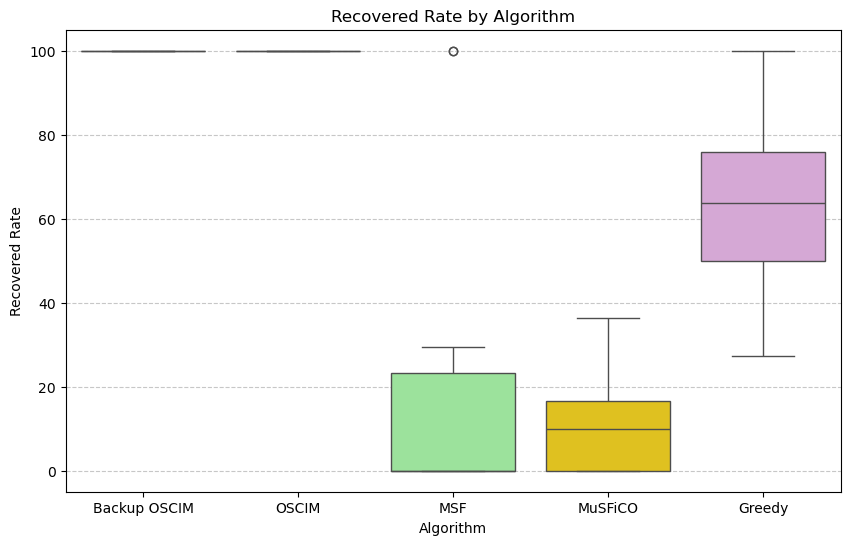

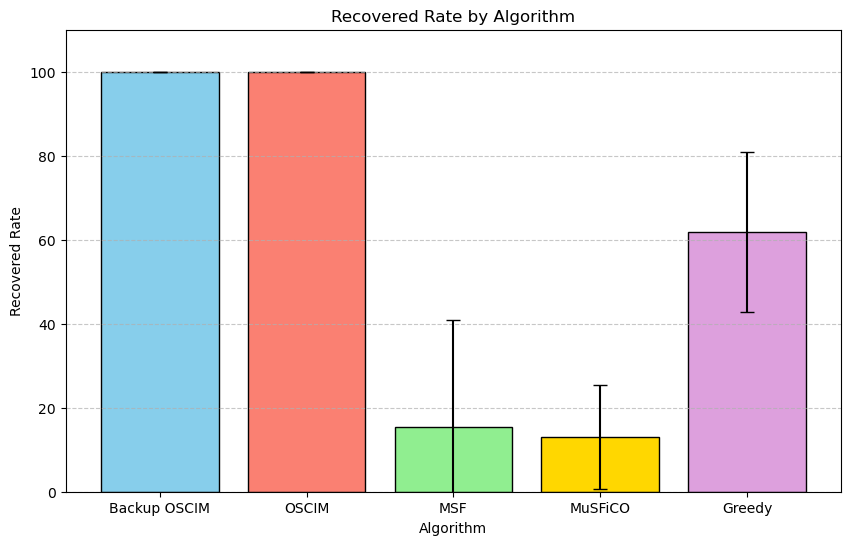

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ordem dos algoritmos e cores correspondentes
algorithms_order = ['Backup OSCIM', 'OSCIM', 'MSF', 'MuSFiCO', 'Greedy']
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum']

# Criar um boxplot usando seaborn com a paleta de cores correspondente
plt.figure(figsize=(10, 6))
sns.boxplot(x='algorithm', y='recovered_rate', data=boxplot_df, 
            palette=dict(zip(algorithms_order, colors)), 
            order=algorithms_order)

# Estilizar o gráfico
plt.title('Recovered Rate by Algorithm')
plt.xlabel('Algorithm')
plt.ylabel('Recovered Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('recovered_rate_boxplot.pdf')

# Exibir a figura
plt.show()

# Calcular a média e o desvio padrão das taxas de recuperação por algoritmo
mean_rates = boxplot_df.groupby('algorithm')['recovered_rate'].mean()
std_rates = boxplot_df.groupby('algorithm')['recovered_rate'].std()

# Criar um barplot usando matplotlib com as mesmas cores e ordem de algoritmos
plt.figure(figsize=(10, 6))
bars = plt.bar(algorithms_order, mean_rates[algorithms_order], yerr=std_rates[algorithms_order], 
               capsize=5, color=colors, edgecolor='black')

# Estilizar o gráfico
plt.title('Recovered Rate by Algorithm')
plt.xlabel('Algorithm')
plt.ylabel('Recovered Rate')
plt.ylim(0, max(mean_rates + std_rates) * 1.1)  # Ajustar o limite superior com uma margem

# Adicionar grade
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('recovered_rate_barplot.pdf')

# Exibir a figura
plt.show()


# Gráfico 2 Recovery Time <a id="gr2"></a>

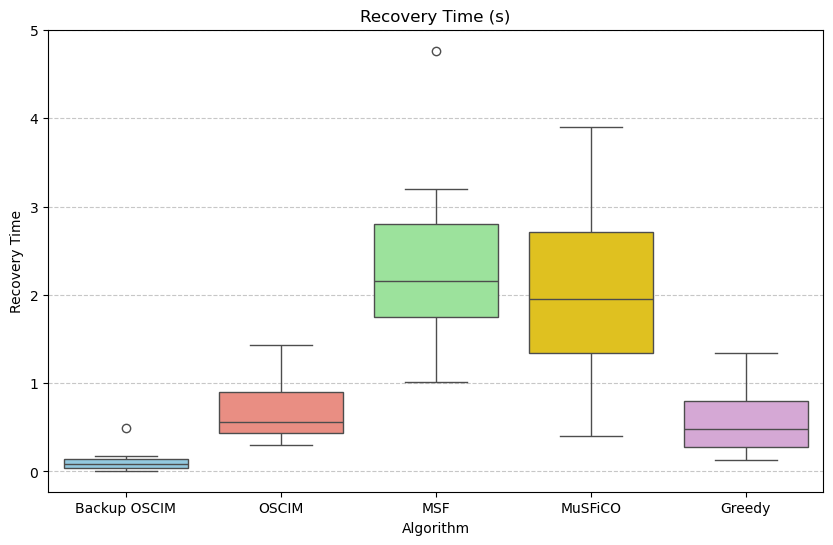

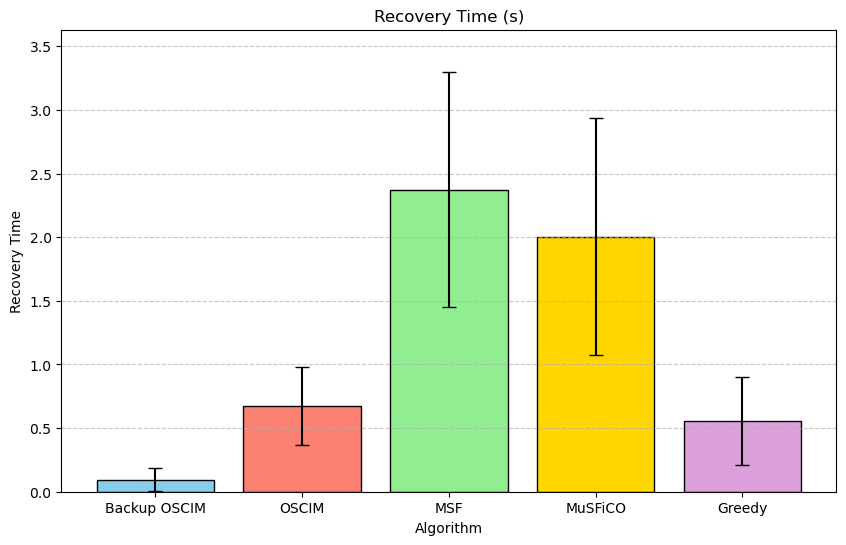

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir a ordem dos algoritmos e as cores correspondentes
algorithms_order = ['Backup OSCIM', 'OSCIM', 'MSF', 'MuSFiCO', 'Greedy']  # Substitua pelos nomes reais dos algoritmos
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum', 'lightcoral']

# Criar o boxplot usando seaborn com a paleta de cores correspondente
plt.figure(figsize=(10, 6))
sns.boxplot(x='algorithm', y='recovery_time', data=boxplot_df, 
            palette=dict(zip(algorithms_order, colors)), 
            order=algorithms_order)

# Estilizar o gráfico
plt.title('Recovery Time (s)')
plt.xlabel('Algorithm')
plt.ylabel('Recovery Time')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('recovery_time_boxplot.pdf')

# Exibir a figura
plt.show()

# Calcular a média e o desvio padrão dos tempos de recuperação por algoritmo
mean_times = boxplot_df.groupby('algorithm')['recovery_time'].mean()
std_times = boxplot_df.groupby('algorithm')['recovery_time'].std()

# Criar um barplot usando matplotlib com as mesmas cores e ordem de algoritmos
plt.figure(figsize=(10, 6))
bars = plt.bar(algorithms_order, mean_times[algorithms_order], yerr=std_times[algorithms_order], 
               capsize=5, color=colors, edgecolor='black')

# Estilizar o gráfico
plt.title('Recovery Time (s)')
plt.xlabel('Algorithm')
plt.ylabel('Recovery Time')
plt.ylim(0, max(mean_times + std_times) * 1.1)  # Ajustar o limite superior com uma margem

# Adicionar grade
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('recovery_time_barplot.pdf')

# Exibir a figura
plt.show()


# Gráfico 3 - latency diff

In [121]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}

def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        
        if simu_exec_name [2] == 'backup':
            alg_name = 'goku_backup'
        else:
            alg_name = simu_exec_name[1].split(f'\\')[1]
        reliability = simu_exec_name[-1]
        if alg_name == 'g':
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'OSCIM'
        if alg_name == 'goku_backup':
            alg_name = 'Backup OSCIM'
        if alg_name == 'musfico':
            alg_name = 'MuSFiCO'
        
        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'reliability': [reliability], 'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:
            log_simu[alg_name]['reliability'].append(reliability)
            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                #print(simulation_df)
                sfc_id_values = simulation_df['sfc_id'].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            simulation_is_success = 'sfc_cache_p4_50' in simulation_df['sfc_id'].values
            
            if simulation_is_success: 
                # Seleciona as métricas relevantes
                simulation_df = simulation_df[metricas_coleta]
                
                # Remove as linhas onde a coluna 'success' é 'None'
                #simulation_df = simulation_df[simulation_df['success'] != 'None']

                # Filtra o DataFrame removendo as linhas onde 'sfc_recovered' é nulo ou 'None'
                latency_diff = simulation_df.dropna(subset=['latency_diff'])                
                latency_diff = latency_diff[latency_diff['latency_diff'] != 'None']
                latency_diff['latency_diff'] = latency_diff['latency_diff'] ** 2

                latency_diff = latency_diff['latency_diff'].mean() 
                #print(latency_diff)

                # Define o nome do algoritmo e incrementa a contagem de simulações
                simulation_df['latency_diff'] = latency_diff
                simulation_df['algorithm'] = alg_name
                simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                
                #print(simulation_df)
                data_nla.append(simulation_df)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]['simulacoes_sucesso'] += 1
                log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())


    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Confiabilidades: {info['reliability']}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [122]:
metricas_coleta = [
    "number_of_sfc",
    "cpu_utilization",
    "bandwidth_utilization",
    "cache_utilization",
    "latency",
    "decision_time_ms",
    "success",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "users_crashed",
    "latency_diff",
]

In [123]:
aggregated_simulation_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)


Resumo das Simulações:
Algoritmo: Backup OSCIM
  Confiabilidades: ['1']
  Quantidade de arquivos: 31
  Simulações de sucesso: 31
  Dados nulos: 75445

Algoritmo: OSCIM
  Confiabilidades: ['1']
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 50833

Algoritmo: Greedy
  Confiabilidades: ['1']
  Quantidade de arquivos: 31
  Simulações de sucesso: 30
  Dados nulos: 44383

Algoritmo: MSF
  Confiabilidades: ['1']
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 58662

Algoritmo: MuSFiCO
  Confiabilidades: ['1']
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 56445



In [124]:
boxplot_df_2 = aggregated_simulation_data.groupby(['algorithm','simulation']).mean().reset_index()

In [128]:
boxplot_df_2[boxplot_df_2['algorithm'] == 'MuSFiCO']

,algorithm,simulation,number_of_sfc,cpu_utilization,bandwidth_utilization,cache_utilization,latency,decision_time_ms,success,crash_moment,recovery_time,sfc_recovered,running_sfcs,running_players,running_sessions,users_crashed,latency_diff
91,MuSFiCO,0,4.0,0.396316,0.165024,0.266587,2.901840,68.342967,0.838046,0.014139,1.965882,0.363636,34.712082,18.044987,4.964010,3.526992,14.25
92,MuSFiCO,1,4.0,0.379642,0.145258,0.258014,2.896721,72.444757,0.794271,0.013021,NaN,0.000000,33.239583,17.341146,4.665365,2.493490,NaN
93,MuSFiCO,2,4.0,0.395288,0.164201,0.265477,2.861111,69.980439,0.835052,0.015464,3.188544,0.166667,34.601804,18.041237,4.980670,3.545103,32.50
94,MuSFiCO,3,4.0,0.393934,0.163139,0.257620,2.826357,69.784690,0.835492,0.014249,0.834922,0.090909,34.753886,18.111399,4.981865,3.000000,81.00
95,MuSFiCO,4,4.0,0.393950,0.163467,0.253229,2.886076,69.119140,0.833773,0.013193,2.037510,0.100000,34.741425,18.029024,4.948549,2.968338,49.00
96,MuSFiCO,5,4.0,0.396417,0.165797,0.261822,2.884676,69.634494,0.829620,0.013106,3.904243,0.100000,34.754915,18.040629,4.989515,3.003932,49.00
97,MuSFiCO,6,4.0,0.382166,0.142377,0.259603,2.814381,74.175502,0.792053,0.013245,NaN,0.000000,33.419868,17.341722,4.737748,2.476821,NaN
98,MuSFiCO,7,4.0,0.396933,0.166647,0.261837,2.882075,70.090984,0.831373,0.013072,0.802595,0.100000,34.879739,18.104575,4.993464,2.996078,49.00
99,MuSFiCO,8,4.0,0.392377,0.166136,0.268217,2.852713,68.832868,0.836576,0.012970,2.706287,0.100000,34.479896,17.994812,4.984436,3.011673,49.00
100,MuSFiCO,9,4.0,0.393233,0.165869,0.262825,2.926332,70.763774,0.828571,0.012987,1.525616,0.100000,34.455844,17.870130,4.961039,3.038961,49.00


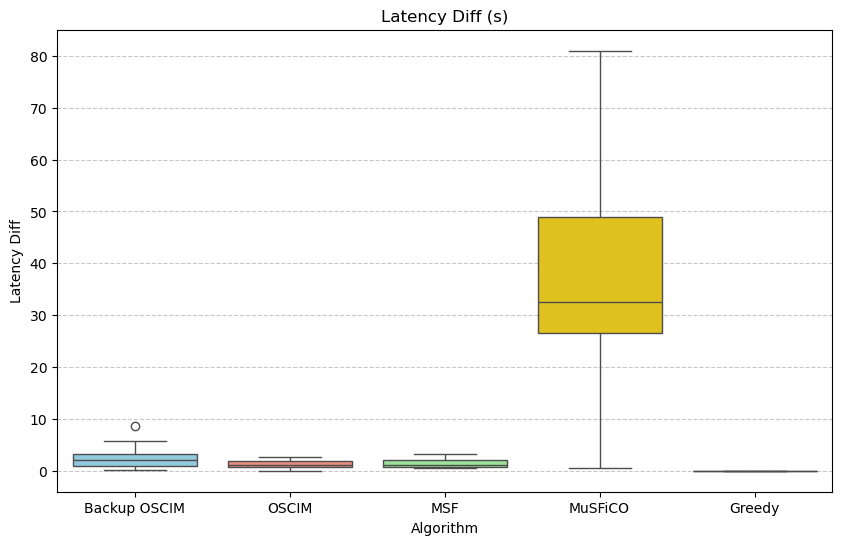

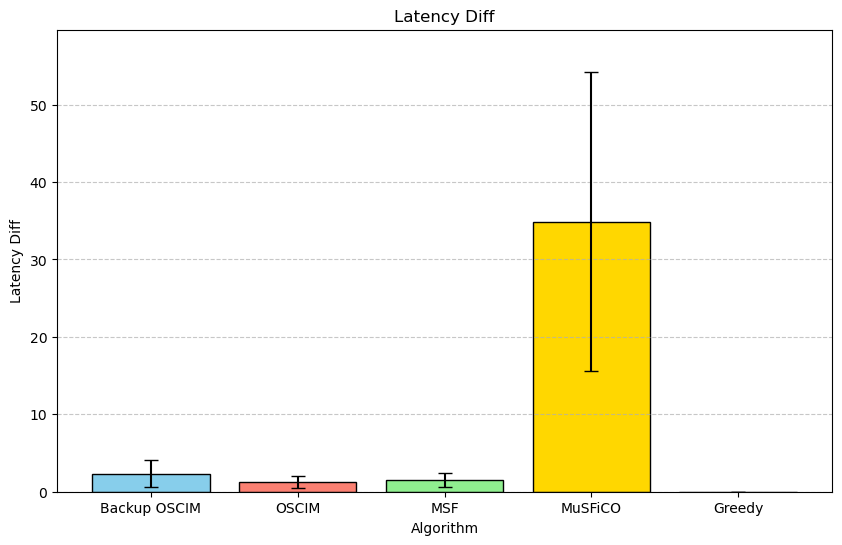

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir a ordem dos algoritmos e as cores correspondentes
algorithms_order = ['Backup OSCIM', 'OSCIM', 'MSF', 'MuSFiCO', 'Greedy']  # Substitua pelos nomes reais dos algoritmos
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum', 'lightcoral']

# Criar o boxplot usando seaborn com a paleta de cores correspondente
plt.figure(figsize=(10, 6))
sns.boxplot(x='algorithm', y='latency_diff', data=boxplot_df_2, 
            palette=dict(zip(algorithms_order, colors)), 
            order=algorithms_order)

# Estilizar o gráfico
plt.title('Latency Diff (s)')
plt.xlabel('Algorithm')
plt.ylabel('Latency Diff')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('latency_diff_boxplot.pdf')

# Exibir a figura
plt.show()

# Calcular a média e o desvio padrão dos tempos de recuperação por algoritmo
mean_times = boxplot_df_2.groupby('algorithm')['latency_diff'].mean()
std_times = boxplot_df_2.groupby('algorithm')['latency_diff'].std()

# Criar um barplot usando matplotlib com as mesmas cores e ordem de algoritmos
plt.figure(figsize=(10, 6))
bars = plt.bar(algorithms_order, mean_times[algorithms_order], yerr=std_times[algorithms_order], 
               capsize=5, color=colors, edgecolor='black')

# Estilizar o gráfico
plt.title('Latency Diff')
plt.xlabel('Algorithm')
plt.ylabel('Latency Diff')
plt.ylim(0, max(mean_times + std_times) * 1.1)  # Ajustar o limite superior com uma margem

# Adicionar grade
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('latency_diff_barplot.pdf')

# Exibir a figura
plt.show()


In [ ]:
boxplot_df_2['utilization_rate'] = boxplot_df_2[['bandwidth_utilization', 'cpu_utilization', 'cache_utilization']].mean(axis=1)

In [ ]:
# Criar o boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='algorithm', y='utilization_rate', data=boxplot_df_2, palette='Set1')

# Estilizar o gráfico
plt.title('Network Space Utilization Rate by Algorithm')
plt.xlabel('Algorithm')
plt.ylabel('Utilization Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('network_utilization_space.pdf')

# Exibir a figura
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Calcular a média e o desvio padrão das taxas de utilização de rede por algoritmo
mean_utilization_rates = boxplot_df_2.groupby('algorithm')['utilization_rate'].mean()
std_utilization_rates = boxplot_df_2.groupby('algorithm')['utilization_rate'].std()

# Definir cores diferentes para cada algoritmo
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum', 'lightcoral']

# Criar um barplot usando matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_utilization_rates.index, mean_utilization_rates, yerr=std_utilization_rates, capsize=5, color=colors, edgecolor='black')

# Estilizar o gráfico
plt.title('Network Space Utilization Rate by Algorithm')
plt.xlabel('Algorithm')
plt.ylabel('Utilization Rate')
plt.ylim(0, max(mean_utilization_rates + std_utilization_rates) * 1.1)  # Ajustar o limite inferior para 0 e o superior com uma margem

# Adicionar grade
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('network_utilization_space_barplot.pdf')

# Exibir a figura
plt.show()


# Gráfico 3 <a id="gr3"></a>

Taxa de perda de benefícios: O quão o usuário foi prejudicado nessa realocação em comparação com a alocação antiga dele

In [ ]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        #print(simu_exec_name)
        alg_name = simu_exec_name[1].split(f'\\')[1]
        reliability = simu_exec_name[-1]
        if alg_name == 'g':
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'Goku'
        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'reliability': [reliability], 'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:
            log_simu[alg_name]['reliability'].append(reliability)
            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                #print(simulation_df)
                sfc_id_values = simulation_df['sfc_id'].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            simulation_is_success = 'sfc_cache_p4_50' in simulation_df['sfc_id'].values
            #print(simulation_is_success)
            if simulation_is_success: 
                # Calcular média acumulada de 'success'
                simulation_df = simulation_df[metricas_coleta]
                cumulative_sum_success = 0
                cumulative_avg_success = []
                for i, value in enumerate(simulation_df['success']):
                    cumulative_sum_success += value
                    cumulative_avg_success.append(cumulative_sum_success / (i + 1))
                
                simulation_df['success'] = cumulative_avg_success
                # Criar a nova coluna com zeros
                
                # Criar a nova coluna com zeros
                simulation_df['latency_diff'] = 0
                simulation_df['benefit_loss_rate'] = 0

                # Filtrar os valores não nulos e diferentes de zero na coluna 'latency'
                valid_latencies = simulation_df['latency'].replace(0, pd.NA).dropna()

                # Definir a latência mínima possível (ideal, sem falha)
                latency_min = valid_latencies.min()

                # Dicionário para armazenar a última latência de cada sfc_id
                last_latency = {}

                # Percorrer o DataFrame para calcular as diferenças de latência e a taxa de perda de benefício
                for index, row in simulation_df.iterrows():
                    sfc_id = row['sfc_id']
                    latency = row['latency']
                    success = row['success']
                    
                    if success:
                        if sfc_id in last_latency:
                            latency_diff = latency - last_latency[sfc_id]
                            simulation_df.at[index, 'latency_diff'] = latency_diff
                            benefit_loss_rate = latency_diff / latency_min
                            simulation_df.at[index, 'benefit_loss_rate'] = benefit_loss_rate
                        last_latency[sfc_id] = latency

                # Calcular ORub como a soma das latências mínimas por sfc_id
                ORub = simulation_df.groupby('sfc_id')['latency'].min().sum()

                # Calcular OR como a soma das latências atuais
                ORe = simulation_df['latency'].sum()
                benefit_loss_rate = (ORub-ORe)/ORub
                simulation_df['benefit_loss_rate_2'] = benefit_loss_rate
                
                simulation_df = simulation_df.dropna()

                #recovered_sfcs = simulation_df['sfc_recovered'].dropna()
                # if alg_name == 'g':
                #     print(recovered_sfcs)
                #     print(file)
                    
                #recovery_rate = recovered_sfcs.mean() * 100

                #simulation_df['recovered_rate'] = recovery_rate
                simulation_df['algorithm'] = alg_name
                simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                
                data_nla.append(simulation_df)

                log_simu[alg_name]['simulacoes_sucesso'] = log_simu[alg_name]['simulacoes_sucesso'] + 1
                log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Confiabilidades: {info['reliability']}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [ ]:
metricas_coleta = [
    "number_of_sfc",
    "cpu_utilization",
    "bandwidth_utilization",
    "cache_utilization",
    "latency",
    "duration",
    "success",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "server_crashed",
    "users_crashed",
    "sfc_id"
]

aggregated_simulation_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)

In [ ]:
aggregated_simulation_data

In [ ]:
grouped_df_3 = aggregated_simulation_data.groupby(['algorithm','simulation']).mean(numeric_only=True)

In [ ]:
grouped_df_3['Relocation Cost2'] = ((grouped_df_3['benefit_loss_rate_2'] - grouped_df_3['benefit_loss_rate_2'].min()) / (grouped_df_3['benefit_loss_rate_2'].max() - grouped_df_3['benefit_loss_rate_2'].min()))*100

In [ ]:
grouped_df_3['Relocation Cost'] = ((grouped_df_3['latency_diff'] - grouped_df_3['latency_diff'].min()) / (grouped_df_3['latency_diff'].max() - grouped_df_3['latency_diff'].min()))*100

In [ ]:
# Criar o boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='algorithm', y='Relocation Cost2', data=grouped_df_3, palette='Set1')

# Estilizar o gráfico
plt.title('Benefit Loss Rate')
plt.xlabel('Algorithm')
plt.ylabel('Benefit Loss Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('Benefit_Loss_Rate.pdf')

# Exibir a figura
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Calcular a média e o desvio padrão dos custos de relocação por algoritmo
mean_relocation_cost = grouped_df_3.groupby('algorithm')['Relocation Cost2'].mean()
std_relocation_cost = grouped_df_3.groupby('algorithm')['Relocation Cost2'].std()

# Definir cores diferentes para cada algoritmo
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum', 'lightcoral']

# Criar um barplot usando matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_relocation_cost.index, mean_relocation_cost, yerr=std_relocation_cost, capsize=5, color=colors, edgecolor='black')

# Estilizar o gráfico
plt.title('Benefit Loss Rate')
plt.xlabel('Algorithm')
plt.ylabel('Benefit Loss Rate')
plt.ylim(0, max(mean_relocation_cost + std_relocation_cost) * 1.1)  # Ajustar o limite inferior para 0 e o superior com uma margem

# Adicionar grade
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('Benefit_Loss_Rate_barplot.pdf')

# Exibir a figura
plt.show()


# Gráfico 4 <a id="gr4"></a>

In [ ]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        #print(simu_exec_name)
        alg_name = simu_exec_name[1].split(f'\\')[1]
        reliability = simu_exec_name[-1]
        if alg_name == 'g':
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'Goku'
        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'reliability': [reliability], 'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:
            log_simu[alg_name]['reliability'].append(reliability)
            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                #print(simulation_df)
                sfc_id_values = simulation_df['sfc_id'].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            simulation_is_success = 'sfc_cache_p4_50' in simulation_df['sfc_id'].values
            #print(simulation_is_success)
            if simulation_is_success: 
                # Calcular média acumulada de 'success'
                simulation_df = simulation_df[metricas_coleta]
                cumulative_sum_success = 0
                cumulative_avg_success = []
                for i, value in enumerate(simulation_df['success']):
                    cumulative_sum_success += value
                    cumulative_avg_success.append(cumulative_sum_success / (i + 1))
                
                simulation_df['success'] = cumulative_avg_success
                execution_time = simulation_df['duration'].mean()
                simulation_df = simulation_df[simulation_df['recovery_time'] != 0]
                for i in simulation_df['recovery_time']:
                    print(i)
                recovery_mean = simulation_df['recovery_time'].mean()
                running_sfcs_mean = simulation_df['running_sfcs'].mean()
                recovery_time_per_sfc = recovery_mean/running_sfcs_mean if running_sfcs_mean != 0  else 0  
                
                if recovery_time_per_sfc == 0 :
                    continue

                simulation_df['recovery_time_per_sfc'] = recovery_time_per_sfc
                simulation_df['recovery_time'] = recovery_mean
                simulation_df['execution_time'] = execution_time
                simulation_df['algorithm'] = alg_name
                simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                
                data_nla.append(simulation_df)

                log_simu[alg_name]['simulacoes_sucesso'] = log_simu[alg_name]['simulacoes_sucesso'] + 1
                log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Confiabilidades: {info['reliability']}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [ ]:
metricas_coleta = [
    "number_of_sfc",
    "cpu_utilization",
    "bandwidth_utilization",
    "cache_utilization",
    "latency",
    "duration",
    "success",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "server_crashed",
    "users_crashed",
    "sfc_id"
]

aggregated_simulation_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)

In [ ]:
aggregated_simulation_data

In [ ]:
grouped_df_4 = aggregated_simulation_data[aggregated_simulation_data['recovery_time'] != 0].groupby(['algorithm','simulation']).mean(numeric_only=True).reset_index()

In [ ]:
grouped_df_4

In [ ]:
# Criar o boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='algorithm', y='recovery_time_per_sfc', data=grouped_df_4, palette='Set1')

# Estilizar o gráfico
plt.title('Recovery Time (s)')
plt.xlabel('Algorithm')
plt.ylabel('Recovery Time')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('recovery_time.pdf')

# Exibir a figura
plt.show()

In [ ]:



import matplotlib.pyplot as plt

# Calcular a média e o desvio padrão dos tempos de recuperação por algoritmo
mean_times = grouped_df_4.groupby('algorithm')['recovery_time_per_sfc'].mean()
std_times = grouped_df_4.groupby('algorithm')['recovery_time_per_sfc'].std()

# Definir cores diferentes para cada algoritmo
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum', 'lightcoral']

# Criar um barplot usando matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_times.index, mean_times, yerr=std_times, capsize=5, color=colors, edgecolor='black')

# Estilizar o gráfico
plt.title('Recovery Time (s)')
plt.xlabel('Algorithm')
plt.ylabel('Recovery Time')
plt.ylim(0, max(mean_times + std_times) * 1.1)  # Ajustar o limite inferior para 0 e o superior com uma margem

# Adicionar grade
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('recovery_time_barplot.pdf')

# Exibir a figura
plt.show()

# Gráfico 5

In [ ]:
boxplot_df['success'] = boxplot_df['success']*100

In [ ]:
# Criar o boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='algorithm', y='success', data=boxplot_df, palette='Set1')

# Estilizar o gráfico
plt.title('Success')
plt.xlabel('Algorithm')
plt.ylabel('Acceptance Ratio (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('Acceptance.pdf')

# Exibir a figura
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Calcular a média e o desvio padrão das taxas de sucesso por algoritmo
mean_success = boxplot_df.groupby('algorithm')['success'].mean()
std_success = boxplot_df.groupby('algorithm')['success'].std()

# Definir cores diferentes para cada algoritmo
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum', 'lightcoral']

# Criar um barplot usando matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_success.index, mean_success, yerr=std_success, capsize=5, color=colors, edgecolor='black')

# Estilizar o gráfico
plt.title('Success')
plt.xlabel('Algorithm')
plt.ylabel('Acceptance Ratio (%)')
plt.ylim(0, max(mean_success + std_success) * 1.1)  # Ajustar o limite inferior para 0 e o superior com uma margem

# Adicionar grade
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('Acceptance_barplot.pdf')

# Exibir a figura
plt.show()
